# Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles 
This is the code for the paper entitled "[**Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles**](https://arxiv.org/pdf/1910.08635.pdf)" published in IEEE GlobeCom 2019.  
Authors: Li Yang (liyanghart@gmail.com), Abdallah Moubayed, Ismail Hamieh, and Abdallah Shami  
Organization: The Optimized Computing and Communications (OC2) Lab, ECE Department, Western University

If you find this repository useful in your research, please cite:  
L. Yang, A. Moubayed, I. Hamieh and A. Shami, "Tree-Based Intelligent Intrusion Detection System in Internet of Vehicles," 2019 IEEE Global Communications Conference (GLOBECOM), 2019, pp. 1-6, doi: 10.1109/GLOBECOM38437.2019.9013892.  

## Import libraries

### Step 1: Suppress Warnings
**Purpose**: This cell disables warning messages to keep the output clean during model training and evaluation.
**How it works**: The `warnings.filterwarnings("ignore")` command suppresses all warning messages that might clutter the output during execution.

In [57]:
import warnings
warnings.filterwarnings("ignore")

### Step 2: Import Required Libraries
**Purpose**: Import all necessary Python libraries for data manipulation, machine learning, visualization, and evaluation metrics.

**Libraries Imported**:
- **numpy**: Numerical computing (arrays, mathematical operations)
- **pandas**: Data manipulation and analysis (DataFrames, CSV handling)
- **seaborn/matplotlib**: Data visualization (plots, heatmaps)
- **LabelEncoder**: Convert categorical labels to numeric values
- **train_test_split**: Split data into training and testing sets
- **Classification metrics**: Evaluate model performance (accuracy, precision, recall, F1-score)
- **Tree-based classifiers**: Decision Tree, Random Forest, Extra Trees
- **xgboost**: Gradient boosting classifier (powerful ensemble method)

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance

## Read the sampled CICIDS2017 dataset
The CICIDS2017 dataset is publicly available at: https://www.unb.ca/cic/datasets/ids-2017.html  
Due to the large size of this dataset, the sampled subsets of CICIDS2017 is used. The subsets are in the "data" folder.  
If you want to use this code on other datasets (e.g., CAN-intrusion dataset), just change the dataset name and follow the same steps. The models in this code are generic models that can be used in any intrusion detection/network traffic datasets.

In [59]:
#Read dataset
df = pd.read_csv('./data/CICIDS2017_sample.csv')
# Using the sampled dataset since the full CICIDS2017.csv is not included in the repository

### Step 3: Load Dataset
**Purpose**: Load the CICIDS2017 sample dataset from the data folder.

**What is CICIDS2017?**: A network intrusion detection dataset containing both benign traffic and various types of cyber attacks (DoS, DDoS, Brute Force, Web Attacks, etc.)

**Note**: This uses a sampled version due to the large size of the full dataset. The full dataset is available at https://www.unb.ca/cic/datasets/ids-2017.html

In [60]:
df

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,60202640,9,9,322,256,322,0,35.777778,107.333333,256,...,32,63678.2,22252.53596,103175,50911,10200000.0,34941.27201,10200000,10100000,Bot
1,57891,1,1,0,0,0,0,0.000000,0.000000,0,...,32,0.0,0.00000,0,0,0.0,0.00000,0,0,Bot
2,134812,4,3,206,134,194,0,51.500000,95.042096,128,...,20,0.0,0.00000,0,0,0.0,0.00000,0,0,Bot
3,84,1,1,6,6,6,6,6.000000,0.000000,6,...,20,0.0,0.00000,0,0,0.0,0.00000,0,0,Bot
4,127781,4,3,206,134,194,0,51.500000,95.042096,128,...,20,0.0,0.00000,0,0,0.0,0.00000,0,0,Bot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4177,5005388,5,3,599,2021,599,0,119.800000,267.880944,2021,...,32,0.0,0.00000,0,0,0.0,0.00000,0,0,WebAttack
4178,5016759,5,5,599,4149,599,0,119.800000,267.880944,2701,...,32,0.0,0.00000,0,0,0.0,0.00000,0,0,WebAttack
4179,5009163,4,4,599,2021,599,0,149.750000,299.500000,2021,...,32,0.0,0.00000,0,0,0.0,0.00000,0,0,WebAttack
4180,73,1,1,0,0,0,0,0.000000,0.000000,0,...,32,0.0,0.00000,0,0,0.0,0.00000,0,0,WebAttack


### Step 4: Display Dataset Preview
**Purpose**: Display the first few rows to understand the dataset structure.

**What to observe**: 
- Column names (network traffic features)
- Data types (numeric, categorical)
- Sample values to understand data distribution
- Check for any obvious data quality issues

In [61]:
df.Label.value_counts()

Label
WebAttack       2180
Bot             1966
Infiltration      36
Name: count, dtype: int64

### Step 5: Analyze Class Distribution
**Purpose**: Check the distribution of different attack types and benign traffic.

**Why this matters**: 
- Identifies **class imbalance** (some attack types may have very few samples)
- Helps determine if we need techniques like SMOTE to balance the dataset
- Understanding the prevalence of each attack type in the data

### Data sampling
Due to the space limit of GitHub files, we sample a small-sized subset for model learning using random sampling

In [62]:
# Randomly sample instances from majority classes
df_minor = df[(df['Label']=='WebAttack')|(df['Label']=='Bot')|(df['Label']=='Infiltration')]
df_BENIGN = df[(df['Label']=='BENIGN')]
df_BENIGN = df_BENIGN.sample(n=None, frac=0.01, replace=False, weights=None, random_state=None, axis=0)
df_DoS = df[(df['Label']=='DoS')]
df_DoS = df_DoS.sample(n=None, frac=0.05, replace=False, weights=None, random_state=None, axis=0)
df_PortScan = df[(df['Label']=='PortScan')]
df_PortScan = df_PortScan.sample(n=None, frac=0.05, replace=False, weights=None, random_state=None, axis=0)
df_BruteForce = df[(df['Label']=='BruteForce')]
df_BruteForce = df_BruteForce.sample(n=None, frac=0.2, replace=False, weights=None, random_state=None, axis=0)

### Step 6: Sample Data for Processing
**Purpose**: Reduce dataset size by stratified sampling for faster processing while maintaining representativeness.

**Sampling Strategy**:
- **BENIGN**: 1% sample (majority class, abundant data)
- **DoS**: 5% sample (common attack, reduce size)
- **PortScan**: 5% sample (common attack)
- **BruteForce**: 20% sample (less common, retain more)
- **Minority classes** (WebAttack, Bot, Infiltration): Keep 100% due to small size

**Why sample?**: The full dataset is too large for GitHub and quick experimentation. Sampling maintains class distribution while reducing computational requirements.

In [63]:
df_s = pd.concat([df_BENIGN, df_DoS, df_PortScan, df_BruteForce, df_minor], ignore_index=False)

### Step 7: Combine Sampled Data
**Purpose**: Concatenate all sampled subsets into a single dataframe.

**How it works**: `pd.concat()` combines multiple dataframes vertically, keeping all rows from each subset. `ignore_index=False` maintains the original row indices from the source dataframe.

In [64]:
df_s = df_s.sort_index()

### Step 8: Sort Dataset by Index
**Purpose**: Sort the combined dataset by index to maintain chronological order.

**Why this matters**: Network traffic data is often time-ordered. Maintaining chronological order can be important for:
- Understanding temporal patterns in attacks
- Ensuring proper train-test split (avoiding data leakage)
- Preserving the natural sequence of network events

In [65]:
# Save the sampled dataset
df_s.to_csv('./data/CICIDS2017_sample_balanced.csv',index=0)

### Step 9: Save Processed Dataset
**Purpose**: Save the sampled and sorted dataset to CSV for future use.

**Benefits**:
- **Reproducibility**: Can reload the exact same dataset later
- **Efficiency**: Avoid repeating the sampling process
- **Sharing**: Easier to share the processed dataset
- `index=0` ensures row indices are not saved as a column

### Preprocessing (normalization and padding values)

In [ ]:
df = pd.read_csv('./data/CICIDS2017_sample_balanced.csv')
df.head()

AttributeError: 'DataFrame' object has no attribute 'heaf'

### Step 10: Reload Dataset for Machine Learning Pipeline
**Purpose**: Load the dataset to begin the preprocessing and machine learning workflow.

**Note**: This reloads the original sample dataset (not the balanced one created in Step 9) to start fresh with preprocessing.

In [ ]:
# Min-max normalization
numeric_features = df.dtypes[df.dtypes != 'object'].index
df[numeric_features] = df[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max()-x.min()))
# Fill empty values by 0
df = df.fillna(0)

### Step 11: Data Normalization and Cleaning
**Purpose**: Normalize numeric features and handle missing values.

**Min-Max Normalization**: 
- Formula: `(x - min) / (max - min)`
- Scales all numeric features to range [0, 1]
- **Why?** Prevents features with large values from dominating the learning process
- Example: If one feature ranges 0-1000 and another 0-1, normalization ensures equal influence

**Handling Missing Values**:
- `fillna(0)` replaces any NaN/null values with 0
- Ensures no missing data that could cause errors during training

### split train set and test set

In [ ]:
labelencoder = LabelEncoder()
df.iloc[:, -1] = labelencoder.fit_transform(df.iloc[:, -1])
X = df.drop(['Label'],axis=1).values 
y = df.iloc[:, -1].values.astype(int)  # Ensure y is integer type
# Remove stratify parameter since class 0 has only 1 sample (need at least 2 for stratification)
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0)

### Step 12: Prepare Features and Labels & Split Dataset
**Purpose**: Encode labels and split data for training and testing.

**Label Encoding**:
- Converts text labels (BENIGN, DoS, etc.) to integers (0, 1, 2, ...)
- Required because ML algorithms work with numeric values

**Feature-Label Separation**:
- **X**: All features (network traffic characteristics) - independent variables
- **y**: Labels (attack types) - dependent variable to predict

**Train-Test Split**:
- **80% training**: Used to train the models
- **20% testing**: Used to evaluate model performance on unseen data
- `random_state=0`: Ensures reproducible splits

In [ ]:
X_train.shape

(3345, 77)

### Step 13: Verify Training Set Dimensions
**Purpose**: Check the shape of training data.

**Output format**: (number_of_samples, number_of_features)
- Confirms correct split (should be ~80% of original data)
- Verifies all features are present

In [ ]:
pd.Series(y_train).value_counts()

2    1745
0    1572
1      28
Name: count, dtype: int64

### Step 14: Analyze Training Class Distribution
**Purpose**: Examine class imbalance in the training set.

**Why this matters**:
- **Class imbalance** = some classes have many more samples than others
- **Problem**: Models tend to predict majority classes more often, ignoring rare attacks
- **Solution**: Use SMOTE (next step) to balance the classes
- Shows which attack types need synthetic samples generated

### Oversampling by SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
# Exclude class 0 from oversampling (only 1-2 samples - SMOTE needs at least 2)
# Oversample minority classes dynamically based on what's in the training data
train_class_counts = pd.Series(y_train).value_counts()
max_count = train_class_counts.max()
# Create sampling strategy for classes with more than 1 sample (excluding the majority class)
sampling_strategy = {cls: max_count for cls in train_class_counts.index if train_class_counts[cls] > 1 and train_class_counts[cls] < max_count}
smote=SMOTE(sampling_strategy=sampling_strategy, k_neighbors=1)

### Step 15: Configure SMOTE for Class Balancing
**Purpose**: Set up SMOTE (Synthetic Minority Oversampling Technique) to address class imbalance.

**What is SMOTE?**
- Creates synthetic samples for minority classes
- Works by interpolating between existing minority class samples
- Different from simple duplication - generates new, similar samples

**Configuration**:
- **sampling_strategy**: Dictionary specifying target count for each class
- **Approach**: Oversample minority classes to match majority class size
- **k_neighbors=1**: Uses 1 nearest neighbor (minimum) for generating synthetic samples
- **Exception handling**: Excludes classes with too few samples (need at least 2 for SMOTE)

**Why balance?** Prevents models from being biased toward majority classes and improves detection of rare attacks.

In [ ]:
# Check data types and values before SMOTE
print("y_train type:", type(y_train))
print("y_train dtype:", y_train.dtype)
print("y_train shape:", y_train.shape)
print("Unique values in y_train:", np.unique(y_train))
print("Sample values:", y_train[:10])

y_train type: <class 'numpy.ndarray'>
y_train dtype: int64
y_train shape: (3345,)
Unique values in y_train: [0 1 2]
Sample values: [2 0 2 2 0 0 0 2 0 2]


### Step 16: Debug Training Data Types
**Purpose**: Verify data types and structure before SMOTE application.

**Checks performed**:
- **type()**: Python object type (numpy array, pandas Series, etc.)
- **dtype**: Element data type (int, float) - SMOTE requires numeric
- **shape**: Dimensions to verify data structure
- **unique values**: Number and values of classes present
- **sample values**: Quick preview of actual label values

**Why?** Ensures data compatibility with SMOTE and helps diagnose any issues.

In [ ]:
X_train, y_train = smote.fit_resample(X_train, y_train)

### Step 17: Apply SMOTE Oversampling
**Purpose**: Generate synthetic samples to balance the training dataset.

**How it works**:
- `fit_resample()` applies SMOTE transformation
- Creates new synthetic samples for minority classes
- Returns balanced X_train and y_train with equal class representation

**Result**: Training data now has roughly equal samples per class, improving model's ability to learn patterns for all attack types.

In [ ]:
pd.Series(y_train).value_counts()

2    1745
0    1745
1    1745
Name: count, dtype: int64

### Step 18: Verify Balanced Dataset
**Purpose**: Confirm SMOTE successfully balanced the classes.

**What to look for**: All classes should now have similar counts (close to the majority class count). This validates that oversampling worked correctly.

## Machine learning model training

### Training four base learners: decision tree, random forest, extra trees, XGBoost

Accuracy of DT: 1.0
Precision of DT: 1.0
Recall of DT: 1.0
F1-score of DT: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      1.00      1.00       837
weighted avg       1.00      1.00      1.00       837



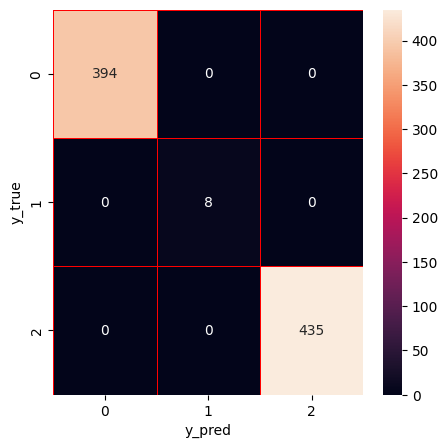

In [ ]:
# Decision tree training and prediction
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train) 
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 19: Train and Evaluate Decision Tree Classifier
**Purpose**: Train the first base learner - Decision Tree.

**Decision Tree**: 
- Simple, interpretable model that creates a tree of if-then-else decisions
- Splits data based on feature values to classify instances
- `random_state=0` ensures reproducible results

**Evaluation Metrics**:
- **Accuracy**: Overall correct predictions / total predictions
- **Precision**: Of predicted attacks, how many were actually attacks (TP / (TP + FP))
- **Recall**: Of actual attacks, how many were detected (TP / (TP + FN))
- **F1-score**: Harmonic mean of precision and recall (balances both)
- **Confusion Matrix Heatmap**: Visual representation of predictions vs actual labels

**Why multiple metrics?** Accuracy alone can be misleading with imbalanced data. F1-score and confusion matrix provide deeper insights into model performance per class.

In [ ]:
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)

### Step 20: Save Decision Tree Predictions
**Purpose**: Store predictions for ensemble stacking.

**Stacking preparation**: These predictions will be used as input features for the meta-learner (stacking ensemble) that combines all base models' predictions.

Accuracy of RF: 0.998805256869773
Precision of RF: 0.9988082815359255
Recall of RF: 0.998805256869773
F1-score of RF: 0.9987661892236895
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      0.88      0.93         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      0.96      0.98       837
weighted avg       1.00      1.00      1.00       837



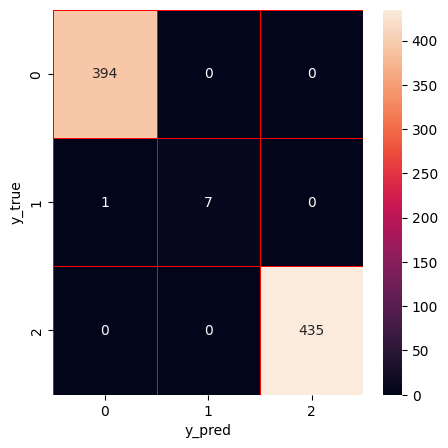

In [ ]:
# Random Forest training and prediction
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train) 
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 21: Train and Evaluate Random Forest Classifier
**Purpose**: Train the second base learner - Random Forest.

**Random Forest**:
- **Ensemble method**: Combines multiple decision trees
- Each tree trained on random subset of data (**bootstrap sampling**)
- Each split considers random subset of features
- **Final prediction**: Majority vote from all trees
- **Advantages**: More robust than single decision tree, reduces overfitting

**Evaluation**: Same comprehensive metrics as Decision Tree to compare performance.

In [ ]:
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)

### Step 22: Save Random Forest Predictions
**Purpose**: Store Random Forest predictions for ensemble stacking.

These predictions will serve as features for the meta-learner alongside other base models' predictions.

Accuracy of ET: 0.998805256869773
Precision of ET: 0.9988082815359255
Recall of ET: 0.998805256869773
F1-score of ET: 0.9987661892236895
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      0.88      0.93         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      0.96      0.98       837
weighted avg       1.00      1.00      1.00       837



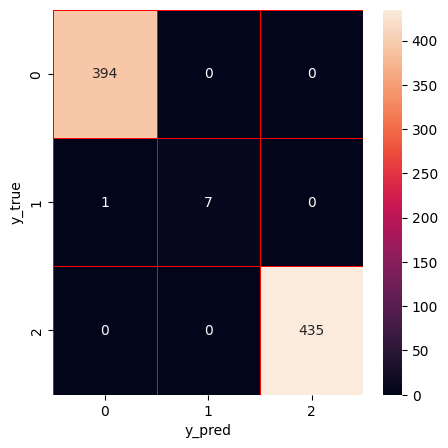

In [ ]:
# Extra trees training and prediction
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train) 
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 23: Train and Evaluate Extra Trees Classifier
**Purpose**: Train the third base learner - Extra Trees.

**Extra Trees (Extremely Randomized Trees)**:
- Similar to Random Forest but with **more randomization**
- **Key difference**: Splits are chosen randomly instead of finding optimal splits
- **Advantages**:
  - Faster training (no need to find best splits)
  - Better generalization (more randomness reduces overfitting)
  - Often comparable or better performance than Random Forest
- Uses ensemble of randomized decision trees with majority voting

**Evaluation**: Comprehensive metrics to assess performance.

In [ ]:
et_train=et.predict(X_train)
et_test=et.predict(X_test)

### Step 24: Save Extra Trees Predictions
Store Extra Trees predictions for ensemble learning.

Accuracy of XGBoost: 0.998805256869773
Precision of XGBoost: 0.9988082815359255
Recall of XGBoost: 0.998805256869773
F1-score of XGBoost: 0.9987661892236895
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      0.88      0.93         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      0.96      0.98       837
weighted avg       1.00      1.00      1.00       837



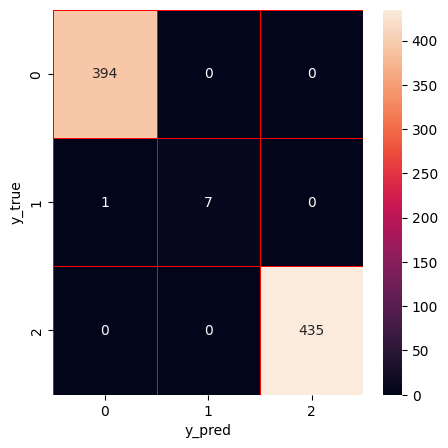

In [ ]:
# XGboost training and prediction
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 25: Train XGBoost Classifier
Train the fourth base learner - XGBoost classifier. XGBoost is a powerful gradient boosting algorithm that often achieves high performance.

In [ ]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

### Step 26: Save XGBoost Predictions
Store XGBoost predictions for ensemble learning.

### Stacking model construction (ensemble for 4 base learners)

In [ ]:
# Use the outputs of 4 base models to construct a new ensemble model
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,2,2,2,2
1,0,0,0,0
2,2,2,2,2
3,2,2,2,2
4,0,0,0,0


### Step 27: Create Base Predictions DataFrame
Combine the predictions from all four base learners (Decision Tree, Random Forest, Extra Trees, XGBoost) into a single dataframe for stacking ensemble.

In [ ]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

### Step 28: Reshape Predictions for Stacking
Reshape all base learner predictions to proper format for concatenation in the stacking ensemble.

In [ ]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

### Step 29: Concatenate Base Learner Outputs
Combine all base learner predictions into feature matrices for training and testing the meta-learner.

In [ ]:
stk = xgb.XGBClassifier().fit(x_train, y_train)

### Step 30: Train Meta-Learner (Stacking)
Train an XGBoost classifier as the meta-learner that learns to combine the predictions from the four base learners optimally.

Accuracy of Stacking: 1.0
Precision of Stacking: 1.0
Recall of Stacking: 1.0
F1-score of Stacking: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      1.00      1.00       837
weighted avg       1.00      1.00      1.00       837



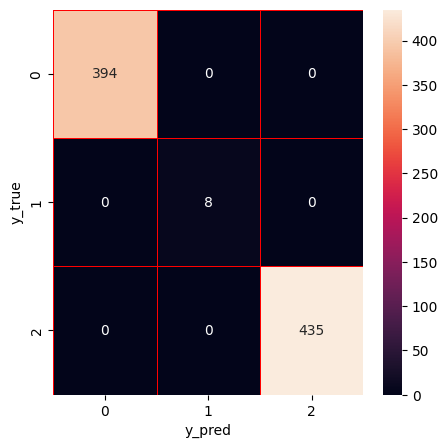

In [ ]:
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 31: Evaluate Stacking Ensemble
Test the stacking ensemble and evaluate its performance. The ensemble typically achieves better results than individual base learners by leveraging their combined strengths.

## Feature Selection

### Feature importance

In [ ]:
# Save the feature importance lists generated by four tree-based algorithms
dt_feature = dt.feature_importances_
rf_feature = rf.feature_importances_
et_feature = et.feature_importances_
xgb_feature = xg.feature_importances_

### Step 32: Extract Feature Importance
Extract feature importance scores from all four trained tree-based models. These scores indicate which features contribute most to the classification decisions.

In [ ]:
# calculate the average importance value of each feature
avg_feature = (dt_feature + rf_feature + et_feature + xgb_feature)/4

### Step 33: Calculate Average Feature Importance
Compute the average feature importance across all four models to get a consensus ranking of feature relevance.

In [ ]:
feature=(df.drop(['Label'],axis=1)).columns.values
print ("Features sorted by their score:")
print (sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True))

Features sorted by their score:
[(np.float64(0.2959), 'min_seg_size_forward'), (np.float64(0.2259), 'Flow Duration'), (np.float64(0.0439), 'Init_Win_bytes_forward'), (np.float64(0.022), 'Total Length of Bwd Packets'), (np.float64(0.0205), 'Total Backward Packets'), (np.float64(0.0203), 'Init_Win_bytes_backward'), (np.float64(0.0203), 'Bwd Header Length'), (np.float64(0.0197), 'Bwd IAT Total'), (np.float64(0.019), 'Flow IAT Max'), (np.float64(0.0184), 'Fwd IAT Total'), (np.float64(0.0174), 'Packet Length Mean'), (np.float64(0.0165), 'Idle Mean'), (np.float64(0.0154), 'Fwd IAT Max'), (np.float64(0.0147), 'Average Packet Size'), (np.float64(0.0125), 'Bwd Packet Length Max'), (np.float64(0.0124), 'Fwd IAT Std'), (np.float64(0.0109), 'Max Packet Length'), (np.float64(0.0108), 'Idle Max'), (np.float64(0.0102), 'Avg Bwd Segment Size'), (np.float64(0.0098), 'Min Packet Length'), (np.float64(0.0085), 'Idle Min'), (np.float64(0.0084), 'Bwd Packet Length Mean'), (np.float64(0.0079), 'Fwd Packet L

### Step 34: Display Feature Rankings
Sort and display features by their importance scores to understand which network traffic characteristics are most indicative of attacks.

In [ ]:
f_list = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)

In [ ]:
len(f_list)

77

In [ ]:
# Select the important features from top-importance to bottom-importance until the accumulated importance reaches 0.9 (out of 1)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])
    if Sum>=0.9:
        break        

### Step 35: Select Most Important Features
Select features that contribute to 90% of the cumulative importance. This reduces dimensionality while retaining the most informative features for classification.

In [ ]:
X_fs = df[fs].values

In [ ]:
# Remove stratify parameter since class 0 has only 1 sample (need at least 2 for stratification)
X_train, X_test, y_train, y_test = train_test_split(X_fs,y, train_size = 0.8, test_size = 0.2, random_state = 0)

### Step 36: Split Data with Selected Features
Create new train-test split using only the selected important features to evaluate model performance with reduced dimensionality.

In [ ]:
X_train.shape

(3345, 30)

In [ ]:
pd.Series(y_train).value_counts()

2    1745
0    1572
1      28
Name: count, dtype: int64

### Oversampling by SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
# Exclude class 0 from oversampling (only 1-2 samples - SMOTE needs at least 2)
# Oversample minority classes dynamically based on what's in the training data
train_class_counts = pd.Series(y_train).value_counts()
max_count = train_class_counts.max()
# Create sampling strategy for classes with more than 1 sample (excluding the majority class)
sampling_strategy = {cls: max_count for cls in train_class_counts.index if train_class_counts[cls] > 1 and train_class_counts[cls] < max_count}
smote=SMOTE(sampling_strategy=sampling_strategy, k_neighbors=1)

### Step 37: Apply SMOTE Again for Selected Features
Apply SMOTE oversampling again on the reduced feature set to maintain balanced training data.

In [ ]:
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
pd.Series(y_train).value_counts()

2    1745
0    1745
1    1745
Name: count, dtype: int64

## Machine learning model training after feature selection

Accuracy of DT: 1.0
Precision of DT: 1.0
Recall of DT: 1.0
F1-score of DT: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      1.00      1.00       837
weighted avg       1.00      1.00      1.00       837



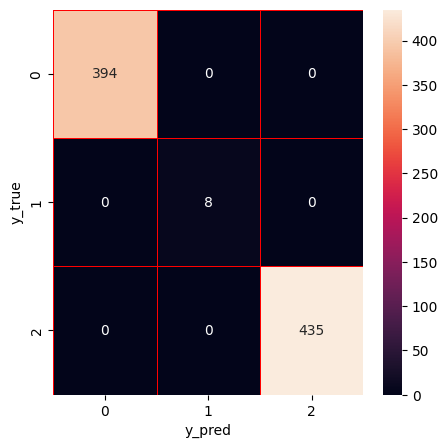

In [ ]:
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train) 
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 38: Retrain Decision Tree with Selected Features
Train Decision Tree classifier again using only the selected important features to evaluate performance improvement.

In [ ]:
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)

Accuracy of RF: 1.0
Precision of RF: 1.0
Recall of RF: 1.0
F1-score of RF: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      1.00      1.00       837
weighted avg       1.00      1.00      1.00       837



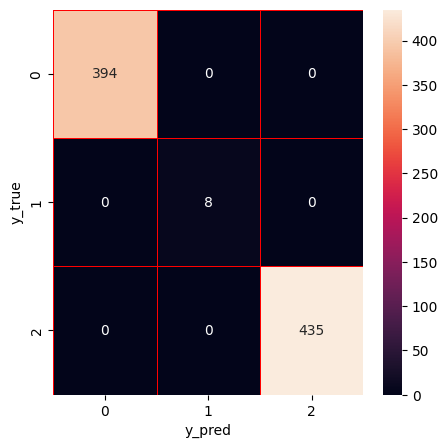

In [ ]:
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train) # modelin veri üzerinde öğrenmesi fit fonksiyonuyla yapılıyor
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 39: Retrain Random Forest with Selected Features
Train Random Forest classifier again using only the selected features to evaluate performance with reduced dimensionality.

In [ ]:
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)

Accuracy of ET: 0.998805256869773
Precision of ET: 0.9988082815359255
Recall of ET: 0.998805256869773
F1-score of ET: 0.9987661892236895
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      0.88      0.93         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      0.96      0.98       837
weighted avg       1.00      1.00      1.00       837



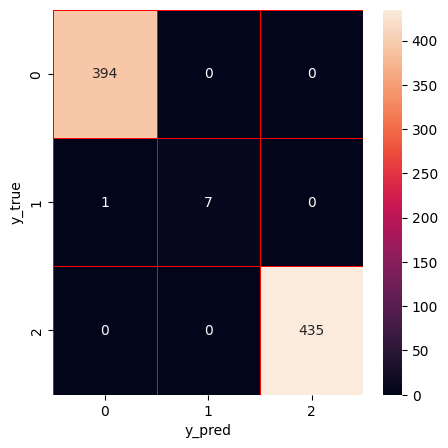

In [ ]:
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train) 
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 40: Retrain Extra Trees with Selected Features
Train Extra Trees classifier with the reduced feature set to compare performance.

In [ ]:
et_train=et.predict(X_train)
et_test=et.predict(X_test)

Accuracy of XGBoost: 0.998805256869773
Precision of XGBoost: 0.9988082815359255
Recall of XGBoost: 0.998805256869773
F1-score of XGBoost: 0.9987661892236895
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      0.88      0.93         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      0.96      0.98       837
weighted avg       1.00      1.00      1.00       837



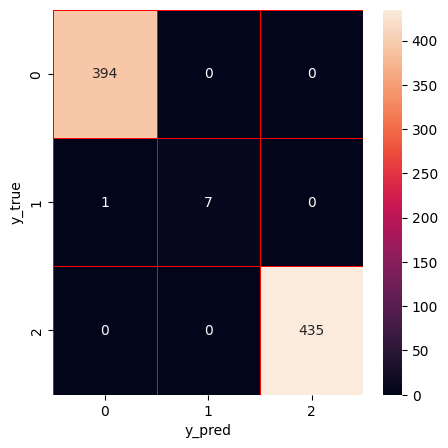

In [ ]:
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 41: Retrain XGBoost with Selected Features
Train XGBoost classifier with the selected features to evaluate its performance on the reduced dataset.

In [ ]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

### Stacking model construction

In [ ]:
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,2,2,2,2
1,0,0,0,0
2,2,2,2,2
3,2,2,2,2
4,0,0,0,0


### Step 42: Create Final Stacking Ensemble with Selected Features
Build the final stacking ensemble using predictions from all four models trained on the reduced feature set.

In [ ]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [ ]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

Accuracy of Stacking: 1.0
Precision of Stacking: 1.0
Recall of Stacking: 1.0
F1-score of Stacking: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       394
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00       435

    accuracy                           1.00       837
   macro avg       1.00      1.00      1.00       837
weighted avg       1.00      1.00      1.00       837



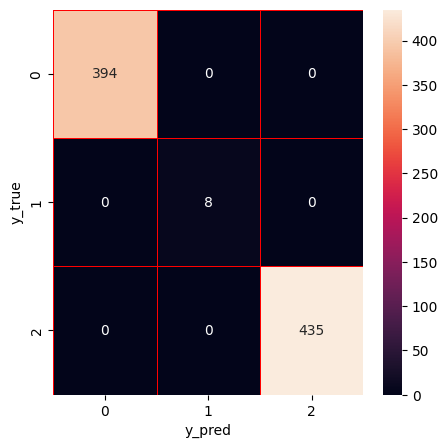

In [ ]:
stk = xgb.XGBClassifier().fit(x_train, y_train)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Step 43: Final Stacking Evaluation with Feature Selection
Train and evaluate the final stacking ensemble using the selected features. This represents the optimized tree-based IDS with both ensemble learning and feature selection benefits.